# 02 — Hypothesis-driven features

Builds features organized by **economic mechanism** rather than one feature at a time. Each block answers a concrete question about the market.

**Feature blocks:**
1. **Momentum** — has price been rising or falling with force?
2. **Mean reversion** — how stretched is price relative to its average?
3. **Trend regime** — does the short-term trend dominate the long-term one?
4. **Relative volatility** — is the market in a volatile or a calm regime relative to normal?
5. **Range tension (high/low)** — is price close to recent extremes?
6. **Curvature** — is price accelerating or decelerating?
7. **Microstructure** — what kind of candle just closed?
8. **Cyclical time** — at what point of the trading session are we?

**Validation:** mutual information with the target, benchmarked against permuted-target noise, plus within-block correlations to discard redundant features.

In [1]:
# === Cell 1: Configuration and imports ===
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

DATA_PATH = pathlib.Path('../data/USDJPY_15M_target.parquet')
OUTPUT_DIR = pathlib.Path('../outputs/reports')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
print(f'Dataset loaded: {len(df):,} rows')
print(f'  Period: {df["Datetime"].min()} → {df["Datetime"].max()}')
print(f'  Target balance: {df["target"].mean():.3f} (TP rate)')

Dataset loaded: 57,345 rows
  Period: 2022-05-20 19:30:00 → 2026-05-27 16:45:00
  Target balance: 0.502 (TP rate)


In [2]:
# === Cell 2: IMPORTANT - rebuild the complete series ===
# The notebook 01 parquet has already dropped NC bars and excluded hours.
# Features with long windows (e.g. SMA200) need the original UNFILTERED series,
# so we reload the raw CSV, compute features on ALL bars, then merge with the target.

RAW_PATH = pathlib.Path('../data/USDJPY_15M.csv')
df_raw = pd.read_csv(RAW_PATH, sep='\t')
rename_map = {
    '<DATE>': 'Date', '<TIME>': 'Time',
    '<OPEN>': 'Open', '<HIGH>': 'High',
    '<LOW>': 'Low', '<CLOSE>': 'Close',
    '<TICKVOL>': 'TickVol', '<VOL>': 'Vol', '<SPREAD>': 'Spread'
}
df_raw = df_raw.rename(columns={k: v for k, v in rename_map.items() if k in df_raw.columns})
df_raw['Datetime'] = pd.to_datetime(df_raw['Date'] + ' ' + df_raw['Time'])
df_raw = df_raw.sort_values('Datetime').reset_index(drop=True)
for c in ['Open', 'High', 'Low', 'Close', 'TickVol', 'Spread']:
    if c in df_raw.columns:
        df_raw[c] = pd.to_numeric(df_raw[c], errors='coerce')

print(f'Raw data loaded: {len(df_raw):,} rows')
print(f'  Features are computed on the COMPLETE series, then merged with the target')

Raw data loaded: 99,976 rows
  Features are computed on the COMPLETE series, then merged with the target


In [3]:
# === Cell 3: BLOCK 1 - Momentum ===
# Hypothesis: direction persists across several time scales
# The windows are chosen to capture different scales:
#   - 5 bars (75 min): fast intraday momentum
#   - 20 bars (5 hours): session momentum
#   - 80 bars (~1 day): daily momentum

for n in [5, 20, 80]:
    df_raw[f'ret_{n}'] = df_raw['Close'].pct_change(n)
    # Z-score of the return, to make it comparable across volatility regimes
    rolling_std = df_raw['Close'].pct_change().rolling(200, min_periods=100).std()
    df_raw[f'ret_{n}_z'] = df_raw[f'ret_{n}'] / (rolling_std * np.sqrt(n))

momentum_cols = ['ret_5', 'ret_20', 'ret_80', 'ret_5_z', 'ret_20_z', 'ret_80_z']
print('BLOCK 1 - Momentum')
print(f'  Features: {momentum_cols}')
print(f'  Hypothesis: the recent direction of price predicts continuation')
print(df_raw[momentum_cols].describe().round(4))

BLOCK 1 - Momentum
  Features: ['ret_5', 'ret_20', 'ret_80', 'ret_5_z', 'ret_20_z', 'ret_80_z']
  Hypothesis: the recent direction of price predicts continuation


            ret_5      ret_20      ret_80     ret_5_z    ret_20_z    ret_80_z
count  99971.0000  99956.0000  99896.0000  99876.0000  99876.0000  99876.0000
mean       0.0000      0.0000      0.0002      0.0207      0.0453      0.1003
std        0.0015      0.0030      0.0060      1.0000      0.9951      1.0039
min       -0.0327     -0.0351     -0.0448    -10.9737     -8.7341     -4.5624
25%       -0.0006     -0.0012     -0.0027     -0.4667     -0.4845     -0.5323
50%        0.0000      0.0001      0.0006      0.0295      0.0564      0.1299
75%        0.0007      0.0014      0.0034      0.5418      0.5986      0.7337
max        0.0217      0.0256      0.0293      7.0196      6.2632      4.5859


In [4]:
# === Cell 4: BLOCK 2 - Mean reversion ===
# Hypothesis: when price is far from its average, it tends to revert
# Distances are measured in ATR units so they are comparable across regimes
# NOTE: no internal shift(1) here; it is applied globally at the merge step

atr_period = 50
tr = pd.concat([
    df_raw['High'] - df_raw['Low'],
    (df_raw['High'] - df_raw['Close'].shift(1)).abs(),
    (df_raw['Low'] - df_raw['Close'].shift(1)).abs()
], axis=1).max(axis=1)
df_raw['atr_50'] = tr.rolling(atr_period, min_periods=atr_period).mean()

for n in [20, 50, 200]:
    sma = df_raw['Close'].rolling(n, min_periods=n).mean()
    df_raw[f'dist_sma_{n}'] = (df_raw['Close'] - sma) / df_raw['atr_50']

reversion_cols = ['dist_sma_20', 'dist_sma_50', 'dist_sma_200']
print('BLOCK 2 - Mean reversion')
print(f'  Features: {reversion_cols}')
print(f'  Hypothesis: an extreme distance from the average implies likely reversion')
print(f'  Units: multiples of ATR (comparable across regimes)')
print(df_raw[reversion_cols].describe().round(3))

BLOCK 2 - Mean reversion
  Features: ['dist_sma_20', 'dist_sma_50', 'dist_sma_200']
  Hypothesis: an extreme distance from the average implies likely reversion
  Units: multiples of ATR (comparable across regimes)
       dist_sma_20  dist_sma_50  dist_sma_200
count    99927.000    99927.000     99777.000
mean         0.070        0.210         0.948
std          1.765        2.786         5.795
min        -23.178      -24.392       -23.783
25%         -0.842       -1.420        -2.937
50%          0.107        0.274         1.056
75%          1.039        1.908         4.893
max         14.151       15.167        23.230


In [5]:
# === Cell 5: BLOCK 3 - Trend regime ===
# Hypothesis: when short SMAs sit above long SMAs, the market is in an uptrend
# The distance BETWEEN averages captures something different from the price-to-average distance

df_raw['sma_20'] = df_raw['Close'].rolling(20, min_periods=20).mean()
df_raw['sma_50'] = df_raw['Close'].rolling(50, min_periods=50).mean()
df_raw['sma_200'] = df_raw['Close'].rolling(200, min_periods=200).mean()

df_raw['regime_20_50'] = (df_raw['sma_20'] - df_raw['sma_50']) / df_raw['atr_50']
df_raw['regime_50_200'] = (df_raw['sma_50'] - df_raw['sma_200']) / df_raw['atr_50']

regime_cols = ['regime_20_50', 'regime_50_200']
print('BLOCK 3 - Trend regime')
print(f'  Features: {regime_cols}')
print(f'  Hypothesis: the ordering of the moving averages defines the directional regime')
print(df_raw[regime_cols].describe().round(3))

BLOCK 3 - Trend regime
  Features: ['regime_20_50', 'regime_50_200']
  Hypothesis: the ordering of the moving averages defines the directional regime
       regime_20_50  regime_50_200
count     99927.000      99777.000
mean          0.140          0.738
std           1.636          4.486
min          -8.708        -19.782
25%          -0.897         -2.255
50%           0.166          0.814
75%           1.171          3.656
max           7.810         16.545


In [6]:
# === Cell 6: BLOCK 4 - Relative volatility ===
# Hypothesis: current volatility relative to its history indicates the regime
# NOTE: no internal shift(1); it is applied globally at the merge step

df_raw['atr_200'] = tr.rolling(200, min_periods=200).mean()
df_raw['vol_ratio'] = df_raw['atr_50'] / df_raw['atr_200']

# Volatility of returns
ret_1 = df_raw['Close'].pct_change()
df_raw['volret_50'] = ret_1.rolling(50, min_periods=50).std()
df_raw['volret_200'] = ret_1.rolling(200, min_periods=200).std()
df_raw['volret_ratio'] = df_raw['volret_50'] / df_raw['volret_200']

vol_cols = ['vol_ratio', 'volret_ratio']
print('BLOCK 4 - Relative volatility')
print(f'  Features: {vol_cols}')
print(f'  Hypothesis: expanding/contracting volatility changes the probability of barrier hits')
print(df_raw[vol_cols].describe().round(3))

BLOCK 4 - Relative volatility
  Features: ['vol_ratio', 'volret_ratio']
  Hypothesis: expanding/contracting volatility changes the probability of barrier hits
       vol_ratio  volret_ratio
count  99777.000     99776.000
mean       1.001         0.960
std        0.231         0.281
min        0.264         0.096
25%        0.847         0.767
50%        0.978         0.937
75%        1.125         1.125
max        3.005         1.996


In [7]:
# === Cell 7: BLOCK 5 - Range tension (high/low) ===
# Hypothesis: near recent highs/lows there are support/resistance zones and asymmetric behavior
# Stochastic-style implementation, but values may leave [-1, 1] on a breakout

for n in [50, 200]:
    rolling_max = df_raw['High'].rolling(n, min_periods=n).max()
    rolling_min = df_raw['Low'].rolling(n, min_periods=n).min()
    rolling_range = rolling_max - rolling_min
    
    # tension = -1 at the low, 0 in the middle, +1 at the high
    # If price breaks the high/low, the value leaves the range (captures breakouts)
    midpoint = (rolling_max + rolling_min) / 2
    df_raw[f'tension_{n}'] = 2 * (df_raw['Close'] - midpoint) / rolling_range

tension_cols = ['tension_50', 'tension_200']
print('BLOCK 5 - Range tension')
print(f'  Features: {tension_cols}')
print(f'  Hypothesis: position relative to recent extremes informs about S/R and breakouts')
print(f'  Range: typically [-1, +1]; |value| > 1 indicates a breakout')
print(df_raw[tension_cols].describe().round(3))
print(f'\n  Upside breakouts (tension>1):    {(df_raw["tension_200"]>1).sum():,}')
print(f'  Downside breakouts (tension<-1): {(df_raw["tension_200"]<-1).sum():,}')

BLOCK 5 - Range tension
  Features: ['tension_50', 'tension_200']
  Hypothesis: position relative to recent extremes informs about S/R and breakouts
  Range: typically [-1, +1]; |value| > 1 indicates a breakout
       tension_50  tension_200
count   99927.000    99777.000
mean        0.107        0.150
std         0.586        0.594
min        -1.000       -1.000
25%        -0.404       -0.368
50%         0.169        0.240
75%         0.638        0.694
max         1.000        1.000

  Upside breakouts (tension>1):    10
  Downside breakouts (tension<-1): 8


In [8]:
# === Cell 8: BLOCK 6 - Curvature (second derivative) ===
# Hypothesis: acceleration/deceleration of price precedes regime changes
# Approximation: difference between a short EMA and a medium EMA (MACD-like in spirit)
# Curvature > 0: price accelerating upward
# Curvature < 0: price accelerating downward (or an uptrend decelerating)

ema_5 = df_raw['Close'].ewm(span=5, adjust=False).mean()
ema_20 = df_raw['Close'].ewm(span=20, adjust=False).mean()
ema_50 = df_raw['Close'].ewm(span=50, adjust=False).mean()

# First derivative (slope proxy)
df_raw['slope_short'] = (ema_5 - ema_20) / df_raw['atr_50']
df_raw['slope_long'] = (ema_20 - ema_50) / df_raw['atr_50']

# Second derivative (curvature): change in the slope
df_raw['curvature'] = df_raw['slope_short'] - df_raw['slope_short'].shift(5)

curvature_cols = ['slope_short', 'slope_long', 'curvature']
print('BLOCK 6 - Curvature')
print(f'  Features: {curvature_cols}')
print(f'  Hypothesis: acceleration/deceleration predicts regime changes')
print(df_raw[curvature_cols].describe().round(3))

BLOCK 6 - Curvature
  Features: ['slope_short', 'slope_long', 'curvature']
  Hypothesis: acceleration/deceleration predicts regime changes


       slope_short  slope_long  curvature
count    99927.000   99927.000  99922.000
mean         0.061       0.145      0.000
std          1.053       1.217      0.748
min         -8.558      -5.323     -8.356
25%         -0.507      -0.632     -0.412
50%          0.087       0.171     -0.005
75%          0.659       0.917      0.421
max          6.460       4.833      7.125


In [9]:
# === Cell 9: BLOCK 7 - Candle microstructure ===
# Hypothesis: the shape of the candle reveals buying/selling pressure
# NOTE: the global shift(1) is applied in the merge cell, not here

range_t = (df_raw['High'] - df_raw['Low']).replace(0, np.nan)

df_raw['body_pct'] = (df_raw['Close'] - df_raw['Open']) / range_t
df_raw['upper_wick'] = (df_raw['High'] - np.maximum(df_raw['Open'], df_raw['Close'])) / range_t
df_raw['lower_wick'] = (np.minimum(df_raw['Open'], df_raw['Close']) - df_raw['Low']) / range_t
df_raw['close_position'] = (df_raw['Close'] - df_raw['Low']) / range_t

micro_cols = ['body_pct', 'upper_wick', 'lower_wick', 'close_position']
print('BLOCK 7 - Candle microstructure')
print(f'  Features: {micro_cols}')
print(f'  Hypothesis: the candle shape reveals immediate pressure')
print(f'  Note: the global shift(1) is applied at the merge (same logic as the other features)')
print(df_raw[micro_cols].describe().round(3))

BLOCK 7 - Candle microstructure
  Features: ['body_pct', 'upper_wick', 'lower_wick', 'close_position']
  Hypothesis: the candle shape reveals immediate pressure
  Note: the global shift(1) is applied at the merge (same logic as the other features)


        body_pct  upper_wick  lower_wick  close_position
count  99974.000   99974.000   99974.000       99974.000
mean       0.020       0.260       0.284           0.522
std        0.525       0.206       0.216           0.301
min       -1.000       0.000       0.000           0.000
25%       -0.434       0.089       0.105           0.254
50%        0.027       0.216       0.242           0.533
75%        0.477       0.391       0.427           0.793
max        1.000       1.000       1.000           1.000


In [10]:
# === Cell 10: BLOCK 8 - Cyclical time ===
# Hypothesis: outcomes vary strongly with the hour of the day (see the hourly table in notebook 01)
# Sin/cos encoding preserves cyclical continuity (hour 23 → 0 without a discontinuity)

df_raw['hour'] = df_raw['Datetime'].dt.hour
df_raw['dayofweek'] = df_raw['Datetime'].dt.dayofweek
df_raw['hour_sin'] = np.sin(2 * np.pi * df_raw['hour'] / 24)
df_raw['hour_cos'] = np.cos(2 * np.pi * df_raw['hour'] / 24)
df_raw['dow_sin'] = np.sin(2 * np.pi * df_raw['dayofweek'] / 5)
df_raw['dow_cos'] = np.cos(2 * np.pi * df_raw['dayofweek'] / 5)

time_cols = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
print('BLOCK 8 - Cyclical time')
print(f'  Features: {time_cols}')
print(f'  Hypothesis: the hour of day and day of week modulate market dynamics')
print(f'  Motivation: in notebook 01 the TP rate ranges from ~11% to ~42% depending on the hour')

BLOCK 8 - Cyclical time
  Features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
  Hypothesis: the hour of day and day of week modulate market dynamics
  Motivation: in notebook 01 the TP rate ranges from ~11% to ~42% depending on the hour


In [11]:
# === Cell 11: Merge with the target dataset ===
# IMPORTANT: shift(1) is applied to ALL price-based features to prevent leakage.
# Reason: entry is simulated at Open[i] and the target evaluates first_hit from there,
# so the features may only use information up to the close of bar i-1
# (the Close of bar i is not yet known at the Open of bar i).

all_feature_cols = (
    momentum_cols + reversion_cols + regime_cols +
    vol_cols + tension_cols + curvature_cols +
    micro_cols + time_cols
)

# Price-based features: shift(1) so they reflect ex-ante information (previous bar's close)
price_based_cols = [c for c in all_feature_cols if c not in time_cols]

# Apply shift(1) ONLY to price-based features
for c in price_based_cols:
    df_raw[c] = df_raw[c].shift(1)

# Time features (hour_sin, hour_cos, dow_sin, dow_cos) are NOT shifted,
# because the time of day is known at the start of the current bar

print('shift(1) applied to price-based features:')
print(f'  Shifted features:      {len(price_based_cols)}')
print(f'  Unshifted features:    {len(time_cols)} (time)')
print(f'  Total features:        {len(all_feature_cols)}')
print()

df_features = df_raw[['Datetime'] + all_feature_cols].copy()

# Merge with the target
df_merged = df.merge(df_features, on='Datetime', how='left')

# Clean inf/nan
for c in all_feature_cols:
    df_merged[c] = df_merged[c].replace([np.inf, -np.inf], np.nan)

n_before = len(df_merged)
df_merged = df_merged.dropna(subset=all_feature_cols).reset_index(drop=True)
n_after = len(df_merged)

print(f'Merge completed')
print(f'  Rows with target:              {n_before:,}')
print(f'  Rows with complete features:   {n_after:,}  ({(n_before-n_after)/n_before*100:.1f}% lost to warm-up)')
print(f'  Total features:             {len(all_feature_cols)}')
print(f'  By block:')
print(f'    Momentum:        {len(momentum_cols)}')
print(f'    Mean reversion:  {len(reversion_cols)}')
print(f'    Regime:          {len(regime_cols)}')
print(f'    Volatility:      {len(vol_cols)}')
print(f'    Tension:         {len(tension_cols)}')
print(f'    Curvature:       {len(curvature_cols)}')
print(f'    Microstructure:  {len(micro_cols)}')
print(f'    Time:            {len(time_cols)}')

shift(1) applied to price-based features:
  Shifted features:      22
  Unshifted features:    4 (time)
  Total features:        26



Merge completed
  Rows with target:              57,345
  Rows with complete features:   57,251  (0.2% lost to warm-up)
  Total features:             26
  By block:
    Momentum:        6
    Mean reversion:  3
    Regime:          2
    Volatility:      2
    Tension:         2
    Curvature:       3
    Microstructure:  4
    Time:            4


In [12]:
# === Cell 11b: Save the UNFILTERED feature set for full-data evaluation ===
# Saves a parallel parquet with the SAME features (shift(1) already applied) over the
# COMPLETE series (every bar, including TIMEOUT bars and excluded hours), plus
# OHLC/atr_exante/cost_pct. Notebook 03 uses it for the realistic full-data evaluation.
#
# Why: the regular parquet is FILTERED (TP/SL bars only). The model is trained on that
# clean data, but a realistic evaluation must apply the model to ALL bars,
# and those bars live here.

TICK_02 = 0.001  # USDJPY — must match TICK in notebook 01

df_raw['atr_exante'] = df_raw['atr_50'].shift(1)
df_raw['cost_pct'] = (df_raw.get('Spread', 0) * TICK_02) / df_raw['Open']

cols_unfiltered = (['Datetime', 'Open', 'High', 'Low', 'Close', 'Spread',
                    'atr_exante', 'cost_pct'] + all_feature_cols)
cols_unfiltered = [c for c in cols_unfiltered if c in df_raw.columns]
df_unfiltered = df_raw[cols_unfiltered].copy()

out_unf = pathlib.Path('../data/USDJPY_15M_features_FULL.parquet')
df_unfiltered.to_parquet(out_unf, index=False)
print(f'UNFILTERED features saved: {out_unf}')
print(f'  Rows (all bars): {len(df_unfiltered):,}')
print(f'  vs filtered: {len(df_merged):,}  → difference = TIMEOUT bars + excluded hours')
print(f'  Features: {len(all_feature_cols)} (shift(1) already applied; notebook 03 subsets them via feature_list.txt)')

UNFILTERED features saved: ../data/USDJPY_15M_features_FULL.parquet
  Rows (all bars): 99,976
  vs filtered: 57,251  → difference = TIMEOUT bars + excluded hours
  Features: 26 (shift(1) already applied; notebook 03 subsets them via feature_list.txt)


In [13]:
# === Cell 12: Mutual information with the target + permuted baseline ===
X = df_merged[all_feature_cols].values
y = df_merged['target'].values

# Actual MI
mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42, n_neighbors=5)

# Baseline MI: permuted target (should be ~0)
# Repeated several times for a robust estimate of the noise level
print('Computing the MI baseline with permuted targets (this sets the noise threshold)...')
n_perms = 5
mi_perm_matrix = np.zeros((n_perms, len(all_feature_cols)))
rng = np.random.default_rng(42)
for p in range(n_perms):
    y_perm = rng.permutation(y)
    mi_perm_matrix[p] = mutual_info_classif(X, y_perm, discrete_features=False, 
                                             random_state=p, n_neighbors=5)
mi_perm_max = mi_perm_matrix.max(axis=0)  # noise ceiling for each feature
mi_perm_mean = mi_perm_matrix.mean(axis=0)

mi_df = pd.DataFrame({
    'feature': all_feature_cols,
    'mi_score': mi_scores,
    'mi_noise_max': mi_perm_max,
    'mi_above_noise': mi_scores - mi_perm_max,
    'signal_ratio': mi_scores / (mi_perm_mean + 1e-10)
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

# Assign each feature to its block
block_map = {}
for c in momentum_cols: block_map[c] = '1.Momentum'
for c in reversion_cols: block_map[c] = '2.Reversion'
for c in regime_cols: block_map[c] = '3.Regime'
for c in vol_cols: block_map[c] = '4.Volatility'
for c in tension_cols: block_map[c] = '5.Tension'
for c in curvature_cols: block_map[c] = '6.Curvature'
for c in micro_cols: block_map[c] = '7.Microstructure'
for c in time_cols: block_map[c] = '8.Time'
mi_df['block'] = mi_df['feature'].map(block_map)
mi_df['informative'] = mi_df['mi_above_noise'] > 0

print('\nMutual information ranking against the target:')
print('  mi_score:        actual MI with the target')
print('  mi_noise_max:    maximum MI with permuted targets (noise threshold)')
print('  mi_above_noise:  margin over the noise (>0 = informative)')
print('  signal_ratio:    actual MI / mean permuted MI (>2 = solid signal)')
print()
print(mi_df.to_string(index=False))
print(f'\nInformative features (above the noise): {mi_df["informative"].sum()} / {len(mi_df)}')

Computing the MI baseline with permuted targets (this sets the noise threshold)...



Mutual information ranking against the target:
  mi_score:        actual MI with the target
  mi_noise_max:    maximum MI with permuted targets (noise threshold)
  mi_above_noise:  margin over the noise (>0 = informative)
  signal_ratio:    actual MI / mean permuted MI (>2 = solid signal)

       feature  mi_score  mi_noise_max  mi_above_noise  signal_ratio            block  informative
  volret_ratio  0.005530      0.002264        0.003266      3.687159     4.Volatility         True
    tension_50  0.005515      0.001288        0.004227     13.494347        5.Tension         True
 regime_50_200  0.003702      0.002217        0.001484      8.183356         3.Regime         True
        ret_80  0.003343      0.004340       -0.000997      3.340906       1.Momentum        False
     curvature  0.003182      0.002853        0.000330      3.244470      6.Curvature         True
  dist_sma_200  0.002611      0.000880        0.001731     14.833074      2.Reversion         True
     vol_ratio 

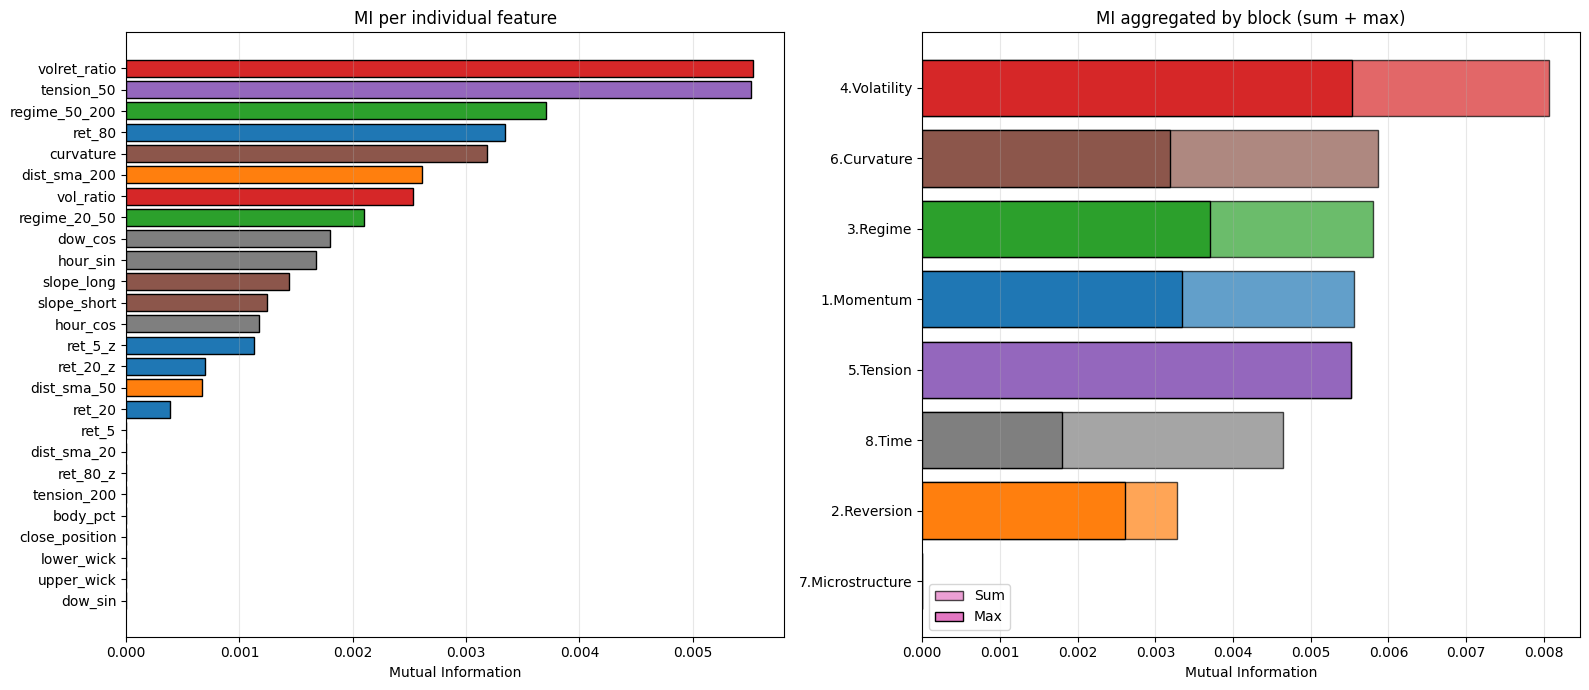


MI aggregated by block:
                      sum     mean      max
block                                      
7.Microstructure  0.00000  0.00000  0.00000
2.Reversion       0.00328  0.00109  0.00261
8.Time            0.00464  0.00116  0.00180
5.Tension         0.00551  0.00276  0.00551
1.Momentum        0.00556  0.00093  0.00334
3.Regime          0.00580  0.00290  0.00370
6.Curvature       0.00587  0.00196  0.00318
4.Volatility      0.00806  0.00403  0.00553


In [14]:
# === Cell 13: MI plots by block ===
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: MI per individual feature
colors_dict = {
    '1.Momentum': '#1f77b4', '2.Reversion': '#ff7f0e', '3.Regime': '#2ca02c',
    '4.Volatility': '#d62728', '5.Tension': '#9467bd', '6.Curvature': '#8c564b',
    '7.Microstructure': '#e377c2', '8.Time': '#7f7f7f'
}
feature_colors = [colors_dict[mi_df.iloc[i]['block']] for i in range(len(mi_df))]

axes[0].barh(mi_df['feature'], mi_df['mi_score'], color=feature_colors, edgecolor='black')
axes[0].invert_yaxis()
axes[0].set_xlabel('Mutual Information')
axes[0].set_title('MI per individual feature')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: MI aggregated by block
block_mi = mi_df.groupby('block')['mi_score'].agg(['sum', 'mean', 'max']).sort_values('sum', ascending=True)
y_pos = np.arange(len(block_mi))
axes[1].barh(y_pos, block_mi['sum'], color=[colors_dict[b] for b in block_mi.index], edgecolor='black', alpha=0.7, label='Sum')
axes[1].barh(y_pos, block_mi['max'], color=[colors_dict[b] for b in block_mi.index], edgecolor='black', label='Max')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(block_mi.index)
axes[1].set_xlabel('Mutual Information')
axes[1].set_title('MI aggregated by block (sum + max)')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mi_features.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nMI aggregated by block:')
print(block_mi.round(5))

In [15]:
# === Cell 14: Within-block correlations (redundancy check) ===
# If two features in the same block have |corr| > 0.85, they are redundant;
# the one with the higher MI is kept

blocks = {
    '1.Momentum': momentum_cols,
    '2.Reversion': reversion_cols,
    '3.Regime': regime_cols,
    '4.Volatility': vol_cols,
    '5.Tension': tension_cols,
    '6.Curvature': curvature_cols,
    '7.Microstructure': micro_cols,
    '8.Time': time_cols
}

redundant_pairs = []
for block_name, cols in blocks.items():
    if len(cols) < 2:
        continue
    corr = df_merged[cols].corr().abs()
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            c = corr.iloc[i, j]
            if c > 0.85:
                mi_i = mi_df[mi_df['feature']==cols[i]]['mi_score'].values[0]
                mi_j = mi_df[mi_df['feature']==cols[j]]['mi_score'].values[0]
                drop = cols[i] if mi_i < mi_j else cols[j]
                redundant_pairs.append((block_name, cols[i], cols[j], c, drop))

if redundant_pairs:
    print('Redundant pairs detected (|corr| > 0.85):')
    for b, f1, f2, c, drop in redundant_pairs:
        print(f'  [{b}] {f1} vs {f2}: corr={c:.3f}  →  drop {drop}')
else:
    print('No within-block redundancy (all correlations < 0.85)')

to_drop = list(set([p[4] for p in redundant_pairs]))
selected_features = [c for c in all_feature_cols if c not in to_drop]
print(f'\nFinal features: {len(selected_features)} (of {len(all_feature_cols)} candidates)')
print(f'  Dropped as redundant: {to_drop}')

Redundant pairs detected (|corr| > 0.85):
  [1.Momentum] ret_5 vs ret_5_z: corr=0.914  →  drop ret_5
  [1.Momentum] ret_20 vs ret_20_z: corr=0.915  →  drop ret_20
  [1.Momentum] ret_80 vs ret_80_z: corr=0.923  →  drop ret_80_z
  [2.Reversion] dist_sma_20 vs dist_sma_50: corr=0.866  →  drop dist_sma_20
  [4.Volatility] vol_ratio vs volret_ratio: corr=0.863  →  drop vol_ratio

Final features: 21 (of 26 candidates)
  Dropped as redundant: ['ret_80_z', 'ret_5', 'ret_20', 'dist_sma_20', 'vol_ratio']


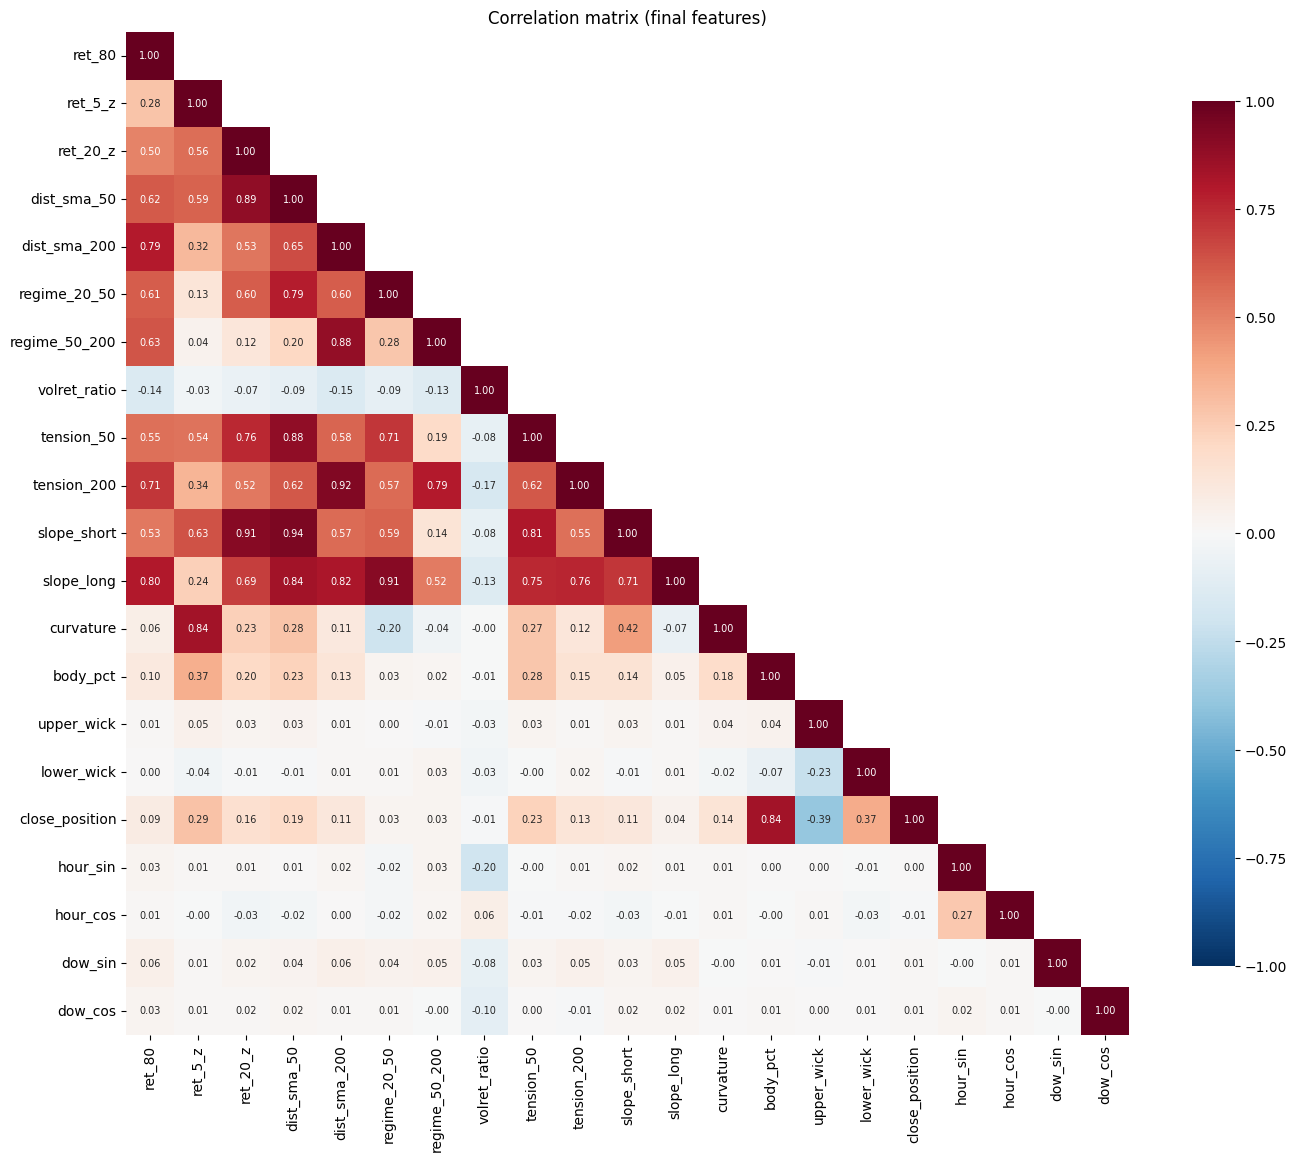


High cross-block correlations (|corr|>0.7):
  dist_sma_50 ↔ slope_short: +0.944
  dist_sma_200 ↔ tension_200: +0.923
  regime_20_50 ↔ slope_long: +0.911
  ret_20_z ↔ slope_short: +0.909
  ret_20_z ↔ dist_sma_50: +0.889
  dist_sma_50 ↔ tension_50: +0.883
  dist_sma_200 ↔ regime_50_200: +0.877
  ret_5_z ↔ curvature: +0.840
  dist_sma_50 ↔ slope_long: +0.840
  dist_sma_200 ↔ slope_long: +0.819
  tension_50 ↔ slope_short: +0.809
  ret_80 ↔ slope_long: +0.803
  regime_50_200 ↔ tension_200: +0.794
  ret_80 ↔ dist_sma_200: +0.789
  dist_sma_50 ↔ regime_20_50: +0.785
  tension_200 ↔ slope_long: +0.760
  ret_20_z ↔ tension_50: +0.756
  tension_50 ↔ slope_long: +0.755
  ret_80 ↔ tension_200: +0.712
  regime_20_50 ↔ tension_50: +0.711


In [16]:
# === Cell 15: Correlation heatmap (visualization) ===
fig, ax = plt.subplots(figsize=(14, 12))
corr_full = df_merged[selected_features].corr()
mask = np.triu(np.ones_like(corr_full, dtype=bool), k=1)
sns.heatmap(corr_full, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', square=True, cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Correlation matrix (final features)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Report high cross-block correlations
high_corr = []
for i, f1 in enumerate(selected_features):
    for j in range(i+1, len(selected_features)):
        f2 = selected_features[j]
        c = corr_full.loc[f1, f2]
        if abs(c) > 0.7 and block_map[f1] != block_map[f2]:
            high_corr.append((f1, f2, c))

if high_corr:
    print('\nHigh cross-block correlations (|corr|>0.7):')
    for f1, f2, c in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'  {f1} ↔ {f2}: {c:+.3f}')
else:
    print('\nNo high cross-block correlations')

In [17]:
# === Cell 16: Save the model-ready dataset ===
cols_final = ['Datetime', 'Open', 'High', 'Low', 'Close', 'atr_exante',
              'tp_pct', 'sl_pct', 'cost_pct', 'first_hit', 'target'] + selected_features

df_out = df_merged[cols_final].reset_index(drop=True)
output_path = pathlib.Path('../data/USDJPY_15M_features.parquet')
df_out.to_parquet(output_path, index=False)

print(f'Feature dataset saved')
print(f'  File:       {output_path}')
print(f'  Rows:       {len(df_out):,}')
print(f'  Features:   {len(selected_features)}')
print()
print('Final features by block:')
for block_name, cols in blocks.items():
    selected_in_block = [c for c in cols if c in selected_features]
    if selected_in_block:
        print(f'  {block_name}: {selected_in_block}')

# Also save the feature list for the next notebook
with open('../data/feature_list.txt', 'w') as f:
    for c in selected_features:
        f.write(c + '\n')
print(f'\nFeature list saved to ../data/feature_list.txt')

Feature dataset saved
  File:       ../data/USDJPY_15M_features.parquet
  Rows:       57,251
  Features:   21

Final features by block:
  1.Momentum: ['ret_80', 'ret_5_z', 'ret_20_z']
  2.Reversion: ['dist_sma_50', 'dist_sma_200']
  3.Regime: ['regime_20_50', 'regime_50_200']
  4.Volatility: ['volret_ratio']
  5.Tension: ['tension_50', 'tension_200']
  6.Curvature: ['slope_short', 'slope_long', 'curvature']
  7.Microstructure: ['body_pct', 'upper_wick', 'lower_wick', 'close_position']
  8.Time: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

Feature list saved to ../data/feature_list.txt
